In [1]:
import torch 
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
import os
from PIL import Image
from collections import Counter
import random

In [2]:
source_folder = ['data_project/train/0', 'data_project/train/1','data_project/test/0','data_project/test/1','data_project/val/0', 'data_project/val/1']
output_folder = ['data_project_gray/train/0', 'data_project_gray/train/1','data_project_gray/test/0','data_project_gray/test/1','data_project_gray/val/0', 'data_project_gray/val/1']

In [ ]:
for folder in output_folder: # makes the file structure for the grayscale images, only need to run once if files aren't already on laptop
    if not os.path.exists(folder):
        os.makedirs(folder)

In [ ]:
# turning the rgb png's into grascale png's, they are saved in the folder we created above 
# if the folder is already on the laptop with all the files, don't use this commando!!
#for i, path in enumerate(source_folder):
    #dest_path = output_folder[i] 
    #for filename in os.listdir(path):
            #if filename.lower().endswith('.png'):
                # Process the image
                #with Image.open(os.path.join(path, filename)) as img:
                    #gray_img = img.convert('L')
                    #gray_img.save(os.path.join(dest_path, filename))

In [3]:
# checking that it worked
img = Image.open('data_project_gray/train/0/9001695L.png') 
print(img.mode)

L


In [4]:
def tensor(path):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),   # ensures 1 channel
        transforms.ToTensor()
    ])
    dataset = datasets.ImageFolder(root=path, transform=transform)
    return dataset

In [5]:
test_dataset = tensor('data_project_gray/test')
train_dataset = tensor('data_project_gray/train')
val_dataset = tensor('data_project_gray/val') 

In [6]:
image, label = train_dataset[0]
print("Tensor shape:", image.shape)   # should be [1, H, W]
print("Label:", label)

Tensor shape: torch.Size([1, 224, 224])
Label: 0


In [7]:
# testing if we really transformed the images to a tensor format 
test_tensor = test_dataset[0]
print(test_tensor) 

(tensor([[[0.5608, 0.5569, 0.5529,  ..., 0.2078, 0.2039, 0.2000],
         [0.5569, 0.5569, 0.5529,  ..., 0.2078, 0.2039, 0.2039],
         [0.5608, 0.5569, 0.5608,  ..., 0.2118, 0.2039, 0.2039],
         ...,
         [0.1137, 0.1255, 0.1490,  ..., 0.4510, 0.3961, 0.3804],
         [0.1216, 0.1333, 0.1490,  ..., 0.4627, 0.4118, 0.4000],
         [0.1216, 0.1216, 0.1490,  ..., 0.4549, 0.4196, 0.4235]]]), 0)


In [8]:
# size of the different datasets 
print(f"size of the test dataset: {len(test_dataset)}")
print(f"size of the training dataset: {len(train_dataset)}")
print(f"size of the validation dataset: {len(val_dataset)}")

size of the test dataset: 146
size of the training dataset: 750
size of the validation dataset: 159


In [9]:
# Distribution

def show_class_distribution(dataset, name):
    counts = Counter(dataset.targets)
    
    print(f"\nClass distribution for {name}:")
    for idx, class_name in enumerate(dataset.classes):
        print(f"{class_name}: {counts[idx]} samples")

show_class_distribution(train_dataset, "training set")
show_class_distribution(val_dataset, "validation set")
show_class_distribution(test_dataset, "test set")


Class distribution for training set:
0: 500 samples
1: 250 samples

Class distribution for validation set:
0: 96 samples
1: 63 samples

Class distribution for test set:
0: 96 samples
1: 50 samples


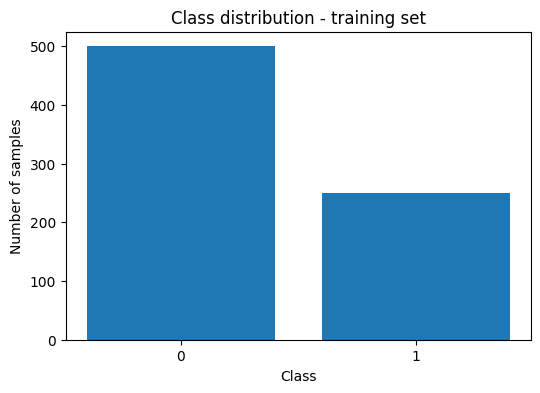

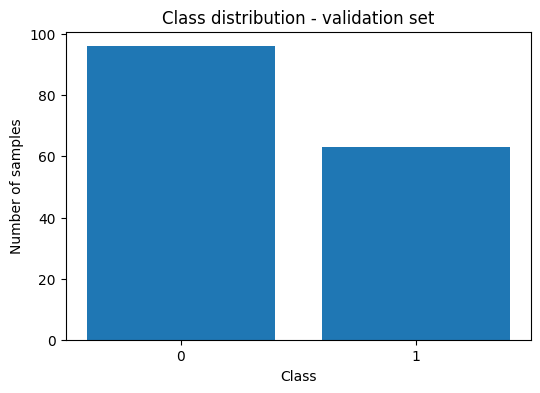

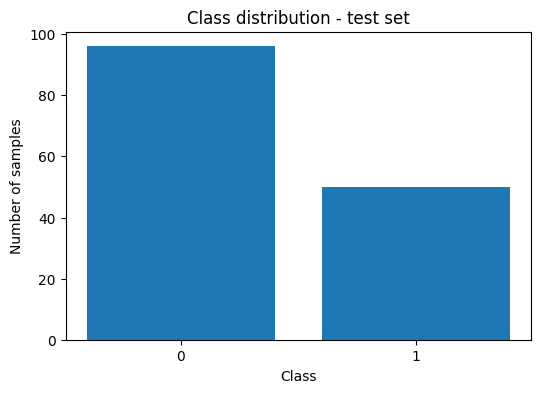

In [10]:


def plot_class_distribution(dataset, name):
    counts = Counter(dataset.targets)
    class_names = dataset.classes
    values = [counts[i] for i in range(len(class_names))]
    
    plt.figure(figsize=(6,4))
    plt.bar(class_names, values)
    plt.title(f"Class distribution - {name}")
    plt.xlabel("Class")
    plt.ylabel("Number of samples")
    plt.show()

plot_class_distribution(train_dataset, "training set")
plot_class_distribution(val_dataset, "validation set")
plot_class_distribution(test_dataset, "test set")

Skipping corrupted image at index 381


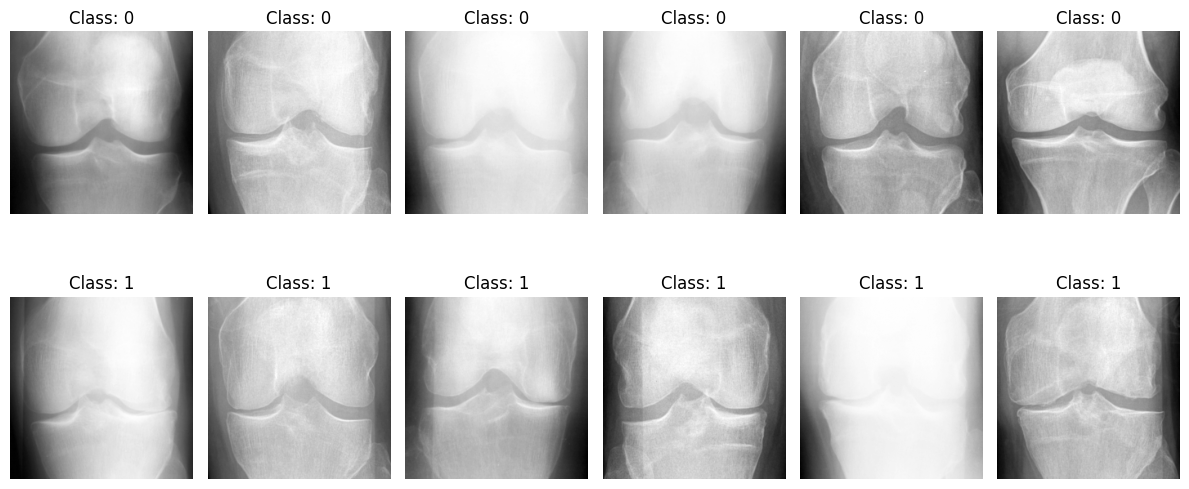

In [11]:
#Plot a few 
from PIL import UnidentifiedImageError

def show_samples_per_class(dataset, samples_per_class=4):
    class_names = dataset.classes
    num_classes = len(class_names)
    
    # track how many images we showed per class
    shown = {i: 0 for i in range(num_classes)}
    
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(12, 3*num_classes))
    
    # fix shape if only 1 class
    if num_classes == 1:
        axes = [axes]
    
    idx = 0
    while not all(shown[i] >= samples_per_class for i in shown):
        try:
            image, label = dataset[idx]
            
            if shown[label] < samples_per_class:
                ax = axes[label][shown[label]]
                ax.imshow(image.squeeze(), cmap='gray')
                ax.set_title(f"Class: {class_names[label]}")
                ax.axis('off')
                shown[label] += 1
                
        except (UnidentifiedImageError, OSError):
            print(f"Skipping corrupted image at index {idx}")
        
        idx += 1
        if idx >= len(dataset):  # safety stop
            break
    
    plt.tight_layout()
    plt.show()

show_samples_per_class(train_dataset, samples_per_class=6)

In [12]:


def dataset_statistics(dataset, name):
    image_means = []
    image_stds = []
    
    pixel_sum = 0.0
    pixel_squared_sum = 0.0
    total_pixels = 0
    
    valid_images = 0
    
    for i in range(len(dataset)):
        try:
            image, _ = dataset[i]   # shape: [1, H, W]
            
            # per-image stats
            image_means.append(image.mean().item())
            image_stds.append(image.std().item())
            
            # global stats
            pixel_sum += image.sum().item()
            pixel_squared_sum += (image ** 2).sum().item()
            total_pixels += image.numel()
            
            valid_images += 1
            
        except (UnidentifiedImageError, OSError):
            print(f"Skipping corrupted image at index {i}")
            continue
    
    global_mean = pixel_sum / total_pixels
    global_std = ((pixel_squared_sum / total_pixels) - (global_mean ** 2)) ** 0.5
    
    print(f"\nStatistics for {name}:")
    print(f"Valid images used: {valid_images}")
    print(f"Average pixel value (mean of means): {sum(image_means)/len(image_means):.4f}")
    print(f"Average std (mean of stds): {sum(image_stds)/len(image_stds):.4f}")
    print(f"Global mean: {global_mean:.4f}")
    print(f"Global std: {global_std:.4f}")
    
    return image_means, image_stds, global_mean, global_std

In [13]:
train_means, train_stds, train_global_mean, train_global_std = dataset_statistics(train_dataset, "training set")

val_means, val_stds, val_global_mean, val_global_std = dataset_statistics(val_dataset, "validation set")

test_means, test_stds, test_global_mean, test_global_std = dataset_statistics(test_dataset, "test set")

Skipping corrupted image at index 381

Statistics for training set:
Valid images used: 749
Average pixel value (mean of means): 0.6060
Average std (mean of stds): 0.1545
Global mean: 0.6060
Global std: 0.1948
Skipping corrupted image at index 111

Statistics for validation set:
Valid images used: 158
Average pixel value (mean of means): 0.6240
Average std (mean of stds): 0.1598
Global mean: 0.6240
Global std: 0.2047

Statistics for test set:
Valid images used: 146
Average pixel value (mean of means): 0.6199
Average std (mean of stds): 0.1580
Global mean: 0.6199
Global std: 0.1927


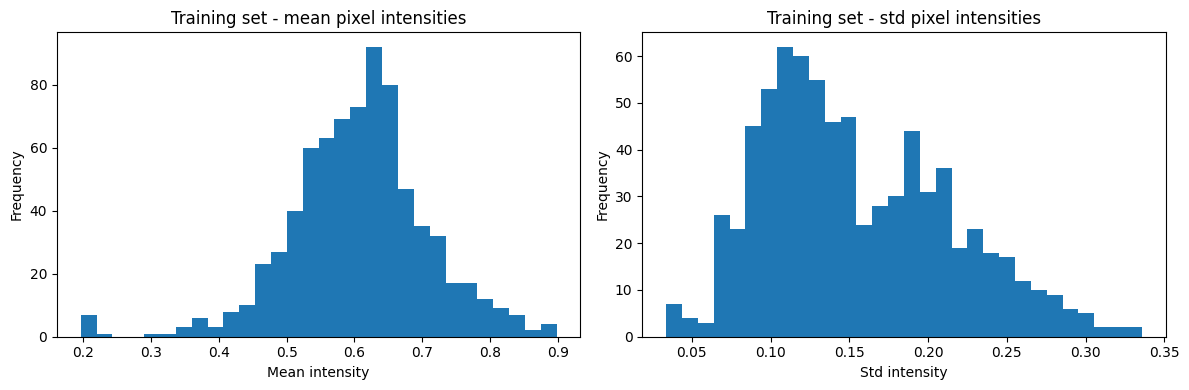

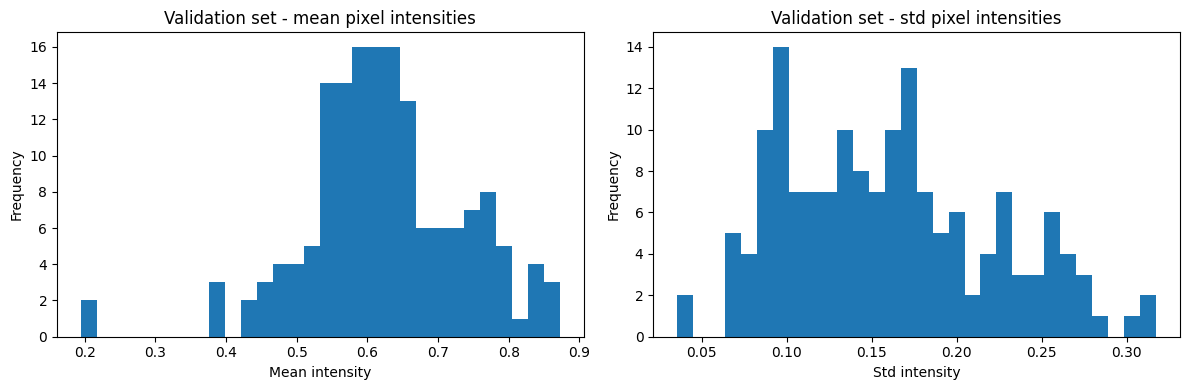

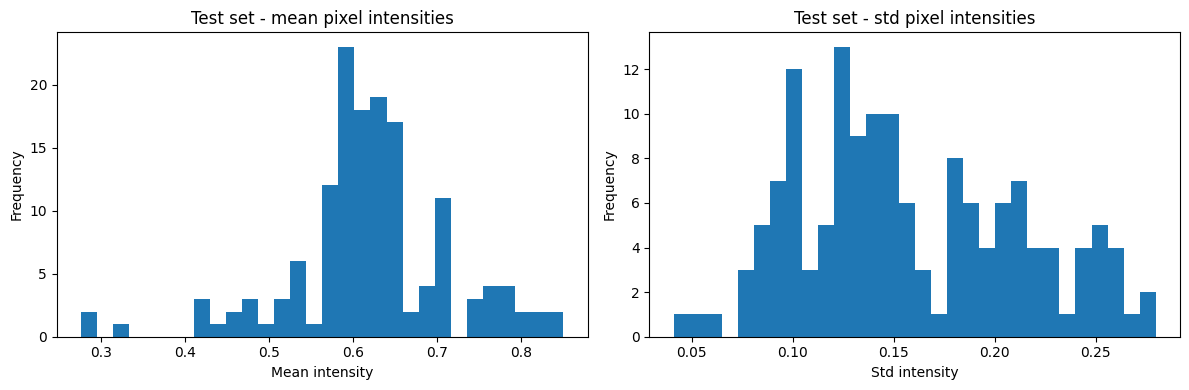

In [14]:


def plot_statistics(means, stds, name):
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    plt.hist(means, bins=30)
    plt.title(f"{name} - mean pixel intensities")
    plt.xlabel("Mean intensity")
    plt.ylabel("Frequency")
    
    plt.subplot(1,2,2)
    plt.hist(stds, bins=30)
    plt.title(f"{name} - std pixel intensities")
    plt.xlabel("Std intensity")
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

plot_statistics(train_means, train_stds, "Training set")
plot_statistics(val_means, val_stds, "Validation set")
plot_statistics(test_means, test_stds, "Test set")

# Preprocessing

In [15]:


def check_image_sizes(dataset, name):
    sizes = []
    skipped = 0
    
    for i in range(len(dataset.samples)):
        path, label = dataset.samples[i]
        try:
            with Image.open(path) as img:
                sizes.append(img.size)   # (width, height)
        except (UnidentifiedImageError, OSError):
            skipped += 1
            print(f"Skipping corrupted image: {path}")
    
    print(f"\n{name}")
    print(f"Valid images checked: {len(sizes)}")
    print(f"Skipped corrupted images: {skipped}")
    
    unique_sizes = Counter(sizes)
    print("Most common image sizes:")
    for size, count in unique_sizes.most_common(10):
        print(f"{size}: {count}")
    
    return sizes

In [16]:
train_sizes = check_image_sizes(train_dataset, "Training set image sizes")
val_sizes = check_image_sizes(val_dataset, "Validation set image sizes")
test_sizes = check_image_sizes(test_dataset, "Test set image sizes")

Skipping corrupted image: data_project_gray/train\0\9184495L.png

Training set image sizes
Valid images checked: 749
Skipped corrupted images: 1
Most common image sizes:
(224, 224): 749
Skipping corrupted image: data_project_gray/val\1\9294761L.png

Validation set image sizes
Valid images checked: 158
Skipped corrupted images: 1
Most common image sizes:
(224, 224): 158

Test set image sizes
Valid images checked: 146
Skipped corrupted images: 0
Most common image sizes:
(224, 224): 146


In [17]:
def tensor_resized(path):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ])
    dataset = datasets.ImageFolder(root=path, transform=transform)
    return dataset

In [18]:
train_dataset = tensor_resized('data_project_gray/train')
val_dataset = tensor_resized('data_project_gray/val')
test_dataset = tensor_resized('data_project_gray/test')

In [19]:
image, label = train_dataset[0]
print("Tensor shape after resizing:", image.shape)

Tensor shape after resizing: torch.Size([1, 128, 128])


In [20]:

# temporary dataset: resize + tensor only, no normalization yet
def tensor_resized_no_norm(path):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ])
    dataset = datasets.ImageFolder(root=path, transform=transform)
    return dataset

train_dataset_no_norm = tensor_resized_no_norm('data_project_gray/train')
val_dataset_no_norm = tensor_resized_no_norm('data_project_gray/val')
test_dataset_no_norm = tensor_resized_no_norm('data_project_gray/test')


def compute_mean_std(dataset):
    pixel_sum = 0.0
    pixel_squared_sum = 0.0
    total_pixels = 0
    valid_images = 0
    
    for i in range(len(dataset)):
        try:
            image, _ = dataset[i]   # shape [1, 128, 128]
            pixel_sum += image.sum().item()
            pixel_squared_sum += (image ** 2).sum().item()
            total_pixels += image.numel()
            valid_images += 1
        except (UnidentifiedImageError, OSError):
            print(f"Skipping corrupted image at index {i}")
            continue
    
    mean = pixel_sum / total_pixels
    std = ((pixel_squared_sum / total_pixels) - mean**2) ** 0.5
    
    print(f"Valid training images used: {valid_images}")
    print(f"Training mean: {mean:.4f}")
    print(f"Training std: {std:.4f}")
    
    return mean, std

train_mean, train_std = compute_mean_std(train_dataset_no_norm)

Skipping corrupted image at index 381
Valid training images used: 749
Training mean: 0.6060
Training std: 0.1944


In [21]:
def tensor_resized_normalized(path, mean, std):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[mean], std=[std])
    ])
    dataset = datasets.ImageFolder(root=path, transform=transform)
    return dataset

train_dataset = tensor_resized_normalized('data_project_gray/train', train_mean, train_std)
val_dataset = tensor_resized_normalized('data_project_gray/val', train_mean, train_std)
test_dataset = tensor_resized_normalized('data_project_gray/test', train_mean, train_std)

Validation sample label: 0
Original image shape: torch.Size([1, 128, 128])
Original mean: 0.7037023305892944
Original std: 0.23171231150627136
Normalized mean: 0.5024434924125671
Normalized std: 1.1918658018112183


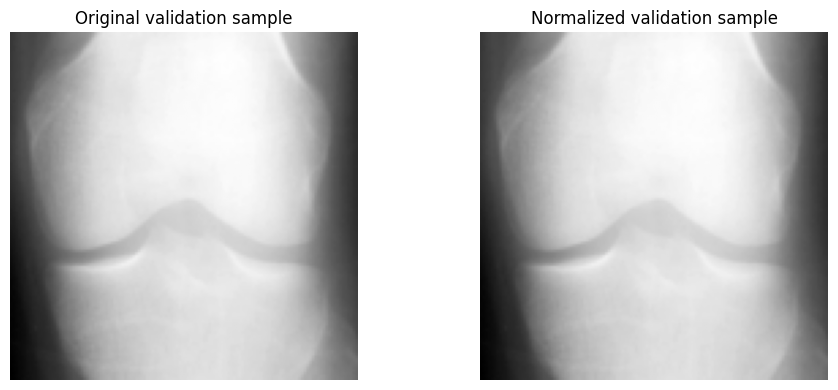

In [22]:

def test_normalization_on_val_sample(val_dataset_no_norm, val_dataset_norm, sample_index=0):
    original_image, label = val_dataset_no_norm[sample_index]
    normalized_image, _ = val_dataset_norm[sample_index]
    
    print("Validation sample label:", label)
    print("Original image shape:", original_image.shape)
    print("Original mean:", original_image.mean().item())
    print("Original std:", original_image.std().item())
    print("Normalized mean:", normalized_image.mean().item())
    print("Normalized std:", normalized_image.std().item())
    
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.imshow(original_image.squeeze(), cmap='gray')
    plt.title("Original validation sample")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(normalized_image.squeeze(), cmap='gray')
    plt.title("Normalized validation sample")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

test_normalization_on_val_sample(
    val_dataset_no_norm,
    val_dataset,
    sample_index=0
)

# Augmentation

In [23]:
train_transform_aug = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    
    # Augmentation 1: small random rotation
    transforms.RandomRotation(degrees=10, fill=0),
    
    # Augmentation 2: small random affine transformation
   transforms.RandomAffine(
    degrees=0,
    translate=(0.05, 0.05),
    scale=(0.95, 1.05),
    fill=0),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

In [24]:
train_dataset_aug = datasets.ImageFolder(
    root='data_project_gray/train',
    transform=train_transform_aug
)

In [25]:


# base preprocessing for visualization
base_transform_vis = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128))
])

# individual augmentations
rotation_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.RandomRotation(degrees=10)
])

affine_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    )
])

# combined augmentations
combined_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    )
])

In [26]:


def load_one_valid_training_image(dataset):
    indices = list(range(len(dataset.samples)))
    random.shuffle(indices)
    
    for i in indices:
        path, label = dataset.samples[i]
        try:
            image = Image.open(path).convert("L")
            return image, label, path
        except (UnidentifiedImageError, OSError):
            print(f"Skipping corrupted image: {path}")
    
    raise ValueError("No valid images found.")

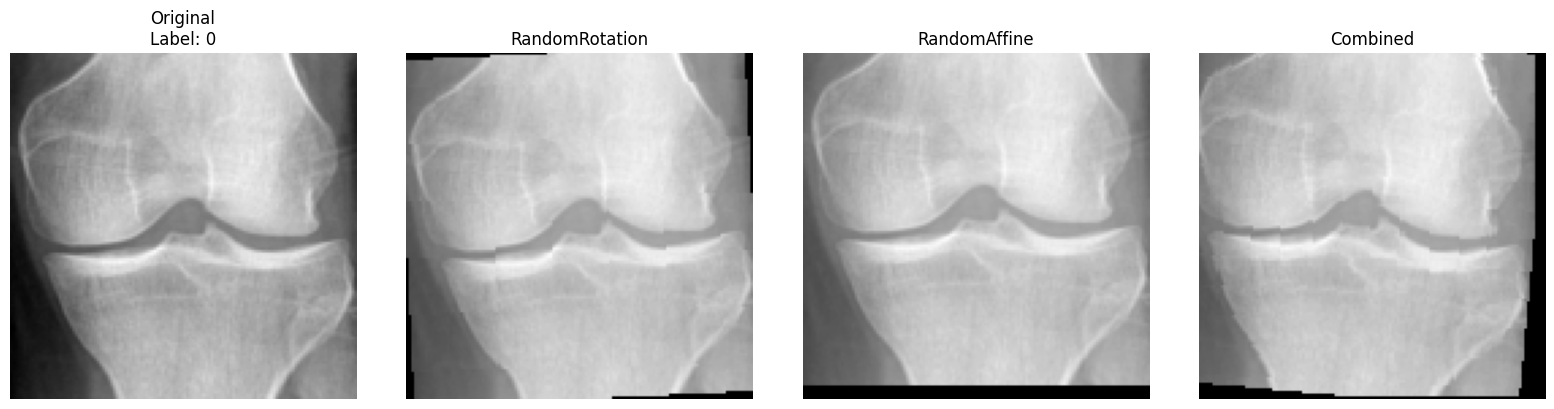

In [27]:
def visualize_augmentations(dataset):
    image, label, path = load_one_valid_training_image(dataset)
    class_name = dataset.classes[label]
    
    original = base_transform_vis(image)
    rotated = rotation_transform(image)
    affined = affine_transform(image)
    combined = combined_transform(image)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title(f"Original\nLabel: {class_name}")
    axes[0].axis('off')
    
    axes[1].imshow(rotated, cmap='gray')
    axes[1].set_title("RandomRotation")
    axes[1].axis('off')
    
    axes[2].imshow(affined, cmap='gray')
    axes[2].set_title("RandomAffine")
    axes[2].axis('off')
    
    axes[3].imshow(combined, cmap='gray')
    axes[3].set_title("Combined")
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_augmentations(train_dataset)

Two data augmentation techniques were applied to the training images: small random rotations and small affine transformations with translation and slight scaling. These augmentations are relevant because knee X-ray images can vary due to differences in patient positioning and acquisition setup. The transformations increase data variability while preserving the anatomical content of the image.

Data augmentation was applied using small random rotations and affine transformations (translation and scaling). These augmentations simulate variations in patient positioning and image acquisition. Care was taken to keep transformations mild to preserve anatomical consistency. To avoid introducing artificial artifacts, empty regions created during transformations were handled appropriately.

# Pipeline

In [28]:


# preprocessing only, no normalization yet
base_transform_no_norm = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset_no_norm = datasets.ImageFolder(
    root='data_project_gray/train',
    transform=base_transform_no_norm
)

def compute_mean_std(dataset):
    pixel_sum = 0.0
    pixel_squared_sum = 0.0
    total_pixels = 0
    valid_images = 0

    for i in range(len(dataset)):
        try:
            image, _ = dataset[i]
            pixel_sum += image.sum().item()
            pixel_squared_sum += (image ** 2).sum().item()
            total_pixels += image.numel()
            valid_images += 1
        except (UnidentifiedImageError, OSError):
            print(f"Skipping corrupted image at index {i}")
            continue

    mean = pixel_sum / total_pixels
    std = ((pixel_squared_sum / total_pixels) - mean**2) ** 0.5

    print("Valid training images used:", valid_images)
    print("Training mean:", round(mean, 4))
    print("Training std:", round(std, 4))

    return mean, std

train_mean, train_std = compute_mean_std(train_dataset_no_norm)

Skipping corrupted image at index 381
Valid training images used: 749
Training mean: 0.606
Training std: 0.1944


In [29]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    
    # augmentation
    transforms.RandomRotation(degrees=10, fill=0),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        fill=0
    ),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

In [30]:
train_dataset = datasets.ImageFolder(
    root='data_project_gray/train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root='data_project_gray/val',
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root='data_project_gray/test',
    transform=eval_transform
)

In [31]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [32]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())

Batch image shape: torch.Size([32, 1, 128, 128])
Batch labels shape: torch.Size([32])
Min pixel value: -3.1172120571136475
Max pixel value: 1.8853185176849365


The preprocessing pipeline consisted of converting images to grayscale, resizing them to 128 × 128 pixels, transforming them into tensors, and normalizing them using the mean and standard deviation of the training set. Data augmentation was applied only to the training set using small random rotations and affine transformations, in order to simulate realistic variation in patient positioning and image acquisition. No augmentation was applied to the validation or test sets, since these sets must represent unchanged data for fair model evaluation.